# EDA – Análise Exploratória de Elogio vs Queixa

Este notebook existe para **entender os dados e o comportamento do modelo**, não para treinar ou melhorar algoritmos.

**Objetivos principais:**
- Compreender a distribuição das classes
- Visualizar características dos textos
- Analisar erros reais do modelo
- Apoiar decisões estratégicas (não ajustes finos ainda)


## Carregamento de bibliotecas

Aqui importamos apenas ferramentas de **análise e visualização**.
Nada de pipeline de produção. Este é um ambiente exploratório.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Carregamento do dataset

Neste bloco carregamos o dataset final já processado,
que foi utilizado no treinamento do modelo.

A visualização inicial (`head`) serve apenas para
confirmar a estrutura, colunas e formato dos dados.


In [ ]:
DATASET_PATH = "../data/processed/comentarios_processados_full.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

## Distribuição das classes
Mostra desbalanceamento do problema.

In [ ]:
df.info()

## Visão geral dos dados

Nesta etapa buscamos responder:
- Quantas linhas existem?
- Quais colunas estão disponíveis?
- Existem valores ausentes?

Nenhuma decisão é tomada aqui. Apenas observação.

## Tamanho dos textos
Comprimento dos comentários por classe.

In [ ]:
df["elogio_ou_queixa"].value_counts()

## Distribuição das classes

Este gráfico mostra o **desbalanceamento do problema**.

Ele explica por que métricas como accuracy podem ser enganosas e por que o modelo tende a favorecer a classe majoritária.

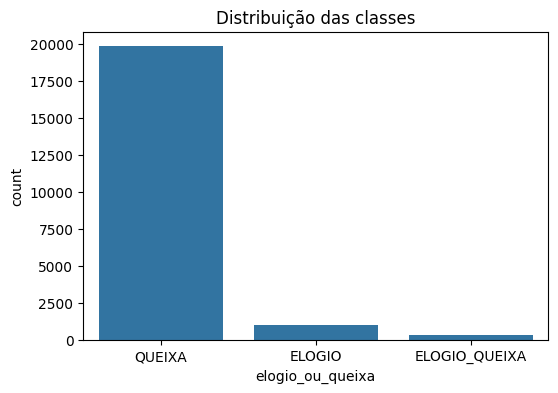

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="elogio_ou_queixa")
plt.title("Distribuição das classes")
plt.show()

## Tamanho dos comentários

Aqui analisamos o comprimento dos textos.

Objetivo:
- Ver se elogios e queixas têm tamanhos diferentes
- Avaliar impacto de textos muito curtos
- Apoiar decisões como `MIN_TEXTO_LEN`

In [ ]:
df["len_comentario"] = df["comentario"].str.len()
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="len_comentario",
    hue="elogio_ou_queixa",
    bins=50,
    element="step",
    stat="density"
)
plt.title("Distribuição do tamanho dos comentários")
plt.show()

## Carregamento do modelo e do vectorizer

Neste bloco carregamos o modelo já treinado e o vectorizer
utilizado no processo de treino.

Esses dois objetos são necessários para:
- transformar comentários em dados numéricos
- permitir que o modelo gere previsões coerentes

Nenhum treinamento é realizado aqui.

In [12]:
import joblib

model_data = joblib.load("../models/elogio_queixa/elogio_queixa.pkl")
model = model_data["model"]
vectorizer = model_data["vectorizer"]

## Aplicação do modelo aos comentários

Neste bloco os comentários são convertidos em representação numérica
usando o mesmo vectorizer do treino.

Em seguida, o modelo gera:
- `y_pred`: a classe prevista para cada comentário

Essas previsões serão comparadas com os rótulos originais (`y_true`)
para analisar acertos, discordâncias e padrões de erro.

In [14]:
X = df["comentario"]
y_true = df["elogio_ou_queixa"]

X_vec = vectorizer.transform(X)
y_pred = model.predict(X_vec)


## Matriz de confusão (avaliação agregada)

Neste bloco analisamos os resultados do modelo de forma agregada.

Antes de gerar a matriz, removemos comentários sem rótulo válido
(`NaN`), pois eles não representam erro de classificação.

A matriz de confusão mostra:
- acertos e erros por classe
- direção predominante das confusões
- limites gerais do modelo

In [ ]:
# remove linhas com rótulo ausente
mask = y_true.notna()

y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]

# matriz de confusão sem mistura de tipos
cm = confusion_matrix(
    y_true_clean,
    y_pred_clean,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão")
plt.show()

## Casos com discordância entre humano e modelo

Neste bloco são exibidos comentários onde o rótulo original do dataset
(`y_true`) é diferente da previsão do modelo (`y_pred`).

Esses casos **não representam necessariamente erro do modelo**.
Eles incluem:
- erros reais de classificação
- rótulos humanos frágeis ou incorretos
- comentários fora do escopo do problema

O objetivo é identificar textos que merecem revisão humana.


In [ ]:
df_erros = df[y_true != y_pred]
df_erros.sample(50)[["comentario", "elogio_ou_queixa"]]
